In [1]:
!pip install tqdm
!pip install torch torchvision torchaudio

In [2]:
# ============================================================
# Imports
# ============================================================

import os
import copy
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    matthews_corrcoef,
    cohen_kappa_score,
    roc_curve,
    precision_recall_curve,
    brier_score_loss
)

from sklearn.calibration import calibration_curve

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torch.utils.data import Dataset
from torch.utils.data import DataLoader

from torch.cuda.amp import autocast
from torch.cuda.amp import GradScaler

from torch.optim.lr_scheduler import CosineAnnealingLR

In [3]:
# ============================================================
# Configuration
# ============================================================

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

BATCH_SIZE = 64

NUM_EPOCHS = 40

LR = 1e-4

WEIGHT_DECAY = 1e-5

NUM_CLASSES = 1

NUM_HEADS = 8

DROPOUT = 0.30

PATIENCE = 8

CHECKPOINT_PATH = "best_fusion_checkpoint.pth"

In [4]:
import os
print(os.getcwd())
print(os.listdir())

/kaggle/working
['FusionModel.pth', '.virtual_documents', 'state.db', 'threshold.npy', 'config.pth', 'best_fusion_model.pth', 'labels.pth', 'best_fusion_model_swa.pth']


In [5]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    if "resnet_model.py" in files:
        print(os.path.join(root, "resnet_model.py"))

/kaggle/input/datasets/shreyasharma03/resnet34-1d/resnet_model.py


In [6]:
!find /kaggle/input -name "resnet_model.py"

/kaggle/input/datasets/shreyasharma03/resnet34-1d/resnet_model.py


In [7]:
import sys
import os

# Add the directory containing your module to sys.path
module_path = "/kaggle/input/datasets/shreyasharma03/resnet34-1d"
if module_path not in sys.path:
    sys.path.append(module_path)

# Now you can import it
import resnet_model
print("Successfully imported!")

Successfully imported!


In [8]:
import inspect
import resnet_model
print(inspect.getsource(resnet_model.ResNet34_1D))

class ResNet34_1D(nn.Module):
    def __init__(self, block=BasicBlock, in_channels=12):
        super().__init__()
        self.in_channels = 64
        self.conv1 = nn.Conv1d(in_channels, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm1d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool1d(kernel_size=3, stride=2, padding=1)

        self.layer1 = self._make_layer(block, 64, 3)
        self.layer2 = self._make_layer(block, 128, 4, stride=2)
        self.layer3 = self._make_layer(block, 256, 6, stride=2)
        self.layer4 = self._make_layer(block, 512, 3, stride=2)

        self.avgpool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(512, 1)   # single logit for binary classification, built directly
        self.feature_dim = 512  # exposed for the fusion notebook to read
        init_weights(self)

    def _make_layer(self, block, out_channels, blocks, stride=1):
        layers = [block(self.in_channels, out_chan

In [9]:
# ============================================================
# Load ResNet34
# ============================================================
import importlib
import resnet_model
importlib.reload(resnet_model)
from resnet_model import ResNet34_1D, BasicBlock

# Remove 'num_classes=1' because the class doesn't accept it
resnet = ResNet34_1D(BasicBlock)

In [10]:
import os
for root, dirs, files in os.walk("/kaggle/input"):
    if "bigru_model.py" in files:
        print(os.path.join(root, "bigru_model.py"))

/kaggle/input/datasets/shreyasharma03/bigru-model/bigru_model.py


In [11]:
import sys
import os
import torch

# 1. Ensure the model definition path is correct
module_path = "/kaggle/input/datasets/shreyasharma03/bigru-model"
if module_path not in sys.path:
    sys.path.append(module_path)

from bigru_model import BiGRUECGClassifier

# 2. Correct the checkpoint path (note the space in 'bigru pth')
# Check the sidebar again: the folder is 'bigru pth', file is 'BIGRU_ECG.pth'
checkpoint_path = "/kaggle/input/bigru-pth/BiGRU_ECG.pth" 

# If that still fails, run the snippet below to find the exact path
# and replace checkpoint_path with the result.

In [12]:
import os

# This will print the exact path for you to copy-paste
for root, dirs, files in os.walk("/kaggle/input"):
    for file in files:
        if "BiGRU_ECG.pth" in file:
            print(f"FOUND: {os.path.join(root, file)}")

FOUND: /kaggle/input/datasets/vidhisidana/bigru-pth/BiGRU_ECG.pth


In [13]:
import torch

checkpoint_path = "/kaggle/input/datasets/vidhisidana/bigru-pth/BiGRU_ECG.pth"
checkpoint = torch.load(checkpoint_path, map_location=DEVICE)

# This will print the keys available in your checkpoint
print(checkpoint.keys())

odict_keys(['encoder.input_bn.weight', 'encoder.input_bn.bias', 'encoder.input_bn.running_mean', 'encoder.input_bn.running_var', 'encoder.input_bn.num_batches_tracked', 'encoder.layers.0.gru.weight_ih_l0', 'encoder.layers.0.gru.weight_hh_l0', 'encoder.layers.0.gru.bias_ih_l0', 'encoder.layers.0.gru.bias_hh_l0', 'encoder.layers.0.gru.weight_ih_l0_reverse', 'encoder.layers.0.gru.weight_hh_l0_reverse', 'encoder.layers.0.gru.bias_ih_l0_reverse', 'encoder.layers.0.gru.bias_hh_l0_reverse', 'encoder.layers.0.norm.weight', 'encoder.layers.0.norm.bias', 'encoder.layers.0.residual_proj.weight', 'encoder.layers.0.residual_proj.bias', 'encoder.layers.1.gru.weight_ih_l0', 'encoder.layers.1.gru.weight_hh_l0', 'encoder.layers.1.gru.bias_ih_l0', 'encoder.layers.1.gru.bias_hh_l0', 'encoder.layers.1.gru.weight_ih_l0_reverse', 'encoder.layers.1.gru.weight_hh_l0_reverse', 'encoder.layers.1.gru.bias_ih_l0_reverse', 'encoder.layers.1.gru.bias_hh_l0_reverse', 'encoder.layers.1.norm.weight', 'encoder.layers.1

In [14]:
import sys
import os
import torch

# Path to your model folder
module_path = "/kaggle/input/datasets/shreyasharma03/bigru-model"
if module_path not in sys.path:
    sys.path.append(module_path)

from bigru_model import BiGRUECGClassifier

bigru = BiGRUECGClassifier()

# Use the full path found in your sidebar
checkpoint_path = "/kaggle/input/datasets/vidhisidana/bigru-pth/BiGRU_ECG.pth"

checkpoint = torch.load(checkpoint_path, map_location=DEVICE)

bigru.load_state_dict(checkpoint)
bigru.to(DEVICE)
bigru.eval()

print("Loaded BiGRU successfully!")

Loaded BiGRU successfully!


In [15]:
# ============================================================
# Module 6 : Load Extracted Features
# ============================================================

import numpy as np

# Define distinct roots based on your sidebar structure
RES_ROOT = "/kaggle/input/datasets/shreyasharma03/resnet34-1d" 
GRU_ROOT = "/kaggle/input/datasets/vidhisidana" 

# Load ResNet features and their corresponding labels
res_train = np.load(f"{RES_ROOT}/resnet_features_train.npy")
y_train = np.load(f"{RES_ROOT}/resnet_labels_train.npy") # Loading labels from ResNet folder

res_val = np.load(f"{RES_ROOT}/resnet_features_val.npy")
y_val = np.load(f"{RES_ROOT}/resnet_labels_val.npy")

res_test = np.load(f"{RES_ROOT}/resnet_features_test.npy")
y_test = np.load(f"{RES_ROOT}/resnet_labels_test.npy")

# Load BiGRU features
gru_train = np.load(f"{GRU_ROOT}/bigru-pth/bigru_features_train.npy")
gru_val = np.load(f"{GRU_ROOT}/bigru-pth/bigru_features_val.npy")
gru_test = np.load(f"{GRU_ROOT}/bigru-pth/bigru_features_test.npy")

print(f"ResNet features shape: {res_train.shape}")
print(f"Labels shape: {y_train.shape}")
print(f"BiGRU features shape: {gru_train.shape}")
# Sanity checks

assert len(res_train) == len(gru_train) == len(y_train)
assert len(res_val) == len(gru_val) == len(y_val)
assert len(res_test) == len(gru_test) == len(y_test)

print("✅ Training set aligned")
print("✅ Validation set aligned")
print("✅ Test set aligned")
print(f"ResNet Feature Dimension : {res_train.shape[1]}")
print(f"BiGRU Feature Dimension  : {gru_train.shape[1]}")

ResNet features shape: (72475, 512)
Labels shape: (72475,)
BiGRU features shape: (72475, 256)
✅ Training set aligned
✅ Validation set aligned
✅ Test set aligned
ResNet Feature Dimension : 512
BiGRU Feature Dimension  : 256


In [16]:
# ============================================================
# Module 7 : Fusion Dataset
# ============================================================

import torch
from torch.utils.data import Dataset

class FusionDataset(Dataset):

    def __init__(self,
                 res_features,
                 gru_features,
                 labels):

        self.res_features = torch.from_numpy(res_features).float()
        self.gru_features = torch.from_numpy(gru_features).float()
        self.labels = torch.from_numpy(labels).float()

    def __len__(self):

        return len(self.labels)

    def __getitem__(self, idx):

        return (

            self.res_features[idx],

            self.gru_features[idx],

            self.labels[idx]

        )

In [17]:
# ============================================================
# Module 8 : DataLoaders
# ============================================================

from torch.utils.data import DataLoader

train_dataset = FusionDataset(
    res_train,
    gru_train,
    y_train
)

val_dataset = FusionDataset(
    res_val,
    gru_val,
    y_val
)

test_dataset = FusionDataset(
    res_test,
    gru_test,
    y_test
)

train_loader = DataLoader(
    train_dataset,
    batch_size=512,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=1024,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1024,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(len(train_loader))
print(len(val_loader))
print(len(test_loader))

142
5
6


In [18]:
# ============================================================
# Module 9 : Verify Data
# ============================================================

res, gru, label = train_dataset[0]

print(res.shape)
print(gru.shape)
print(label)

print()

batch = next(iter(train_loader))

print(batch[0].shape)
print(batch[1].shape)
print(batch[2].shape)

torch.Size([512])
torch.Size([256])
tensor(0.)

torch.Size([512, 512])
torch.Size([512, 256])
torch.Size([512])


In [19]:
# ============================================================
# Module 10 : Adaptive Reliability Fusion
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F

class AdaptiveReliabilityFusion(nn.Module):

    def __init__(self,
                 res_dim=512,
                 gru_dim=256,
                 embed_dim=512,
                 heads=8,
                 dropout=0.30):

        super().__init__()

        self.res_proj = nn.Linear(res_dim, embed_dim)

        self.gru_proj = nn.Linear(gru_dim, embed_dim)

        self.res_conf = nn.Sequential(

            nn.Linear(embed_dim,128),

            nn.GELU(),

            nn.Linear(128,1)

        )

        self.gru_conf = nn.Sequential(

            nn.Linear(embed_dim,128),

            nn.GELU(),

            nn.Linear(128,1)

        )

        self.attn = nn.MultiheadAttention(

            embed_dim,

            heads,

            dropout=dropout,

            batch_first=True

        )

        self.norm = nn.LayerNorm(embed_dim)

        self.ffn = nn.Sequential(

            nn.Linear(embed_dim,embed_dim),

            nn.GELU(),

            nn.Dropout(dropout),

            nn.Linear(embed_dim,embed_dim)

        )

        self.dropout = nn.Dropout(dropout)

    def forward(self,res,gru):

        res=self.res_proj(res)

        gru=self.gru_proj(gru)

        res_score=self.res_conf(res)

        gru_score=self.gru_conf(gru)

        weights=torch.softmax(

            torch.cat([res_score,gru_score],1),

            dim=1

        )

        alpha_res=weights[:,0:1]

        alpha_gru=weights[:,1:2]

        res=res*alpha_res

        gru=gru*alpha_gru

        tokens=torch.stack([res,gru],1)

        fused,_=self.attn(tokens,tokens,tokens)

        fused=fused.mean(1)

        fused=self.norm(

            fused+self.ffn(fused)

        )

        fused=self.dropout(fused)

        return fused,alpha_res,alpha_gru

In [20]:
# ============================================================
# Module 11 : Fusion Classifier
# ============================================================

class ECGFusionClassifier(nn.Module):

    def __init__(self):

        super().__init__()

        self.fusion=AdaptiveReliabilityFusion()

        self.classifier=nn.Sequential(

            nn.Linear(512,512),

            nn.LayerNorm(512),

            nn.GELU(),

            nn.Dropout(0.30),

            nn.Linear(512,256),

            nn.LayerNorm(256),

            nn.GELU(),

            nn.Dropout(0.20),

            nn.Linear(256,64),

            nn.GELU(),

            nn.Linear(64,1)

        )

    def forward(self,res,gru):

        fused,alpha_res,alpha_gru=self.fusion(res,gru)

        logits=self.classifier(fused).squeeze(1)

        return logits,fused,alpha_res,alpha_gru

In [21]:
# ============================================================
# Module 12 : Build Model
# ============================================================

DEVICE=torch.device("cuda" if torch.cuda.is_available() else "cpu")

model=ECGFusionClassifier().to(DEVICE)

print(model)

total=sum(p.numel() for p in model.parameters())

trainable=sum(p.numel() for p in model.parameters() if p.requires_grad)

print()

print("Total Parameters :",total)

print("Trainable :",trainable)

ECGFusionClassifier(
  (fusion): AdaptiveReliabilityFusion(
    (res_proj): Linear(in_features=512, out_features=512, bias=True)
    (gru_proj): Linear(in_features=256, out_features=512, bias=True)
    (res_conf): Sequential(
      (0): Linear(in_features=512, out_features=128, bias=True)
      (1): GELU(approximate='none')
      (2): Linear(in_features=128, out_features=1, bias=True)
    )
    (gru_conf): Sequential(
      (0): Linear(in_features=512, out_features=128, bias=True)
      (1): GELU(approximate='none')
      (2): Linear(in_features=128, out_features=1, bias=True)
    )
    (attn): MultiheadAttention(
      (out_proj): NonDynamicallyQuantizableLinear(in_features=512, out_features=512, bias=True)
    )
    (norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (ffn): Sequential(
      (0): Linear(in_features=512, out_features=512, bias=True)
      (1): GELU(approximate='none')
      (2): Dropout(p=0.3, inplace=False)
      (3): Linear(in_features=512, out_feature

In [22]:
# ============================================================
# Module 13 : Forward Test
# ============================================================

res,gru,label=next(iter(train_loader))

res=res.to(DEVICE)

gru=gru.to(DEVICE)

model.eval()

with torch.no_grad():

    logits,fused,alpha_res,alpha_gru=model(res,gru)

print(logits.shape)

print(fused.shape)

print(alpha_res.shape)

print(alpha_gru.shape)

torch.Size([512])
torch.Size([512, 512])
torch.Size([512, 1])
torch.Size([512, 1])


In [23]:
# ============================================================
# Module 14 : Automatic Class Weight
# ============================================================

import torch
import numpy as np

positive = np.sum(y_train == 1)
negative = np.sum(y_train == 0)

print("Positive :", positive)
print("Negative :", negative)

POS_WEIGHT = torch.tensor(
    [negative / positive],
    dtype=torch.float32
).to(DEVICE)

print("Pos Weight =", POS_WEIGHT.item())

Positive : 16962
Negative : 55513
Pos Weight = 3.2727861404418945


In [24]:
# ============================================================
# Module 15 : Hybrid BCE + Focal Loss
# ============================================================

class HybridLoss(nn.Module):

    def __init__(
        self,
        pos_weight,
        alpha=0.25,
        gamma=2,
        focal_weight=0.30,
        bce_weight=0.70
    ):

        super().__init__()

        self.alpha = alpha
        self.gamma = gamma

        self.focal_weight = focal_weight
        self.bce_weight = bce_weight

        self.bce = nn.BCEWithLogitsLoss(
            pos_weight=pos_weight
        )

    def forward(self, logits, labels):

        bce = self.bce(logits, labels)

        prob = torch.sigmoid(logits)

        pt = torch.where(
            labels == 1,
            prob,
            1 - prob
        )

        focal = -self.alpha * ((1-pt)**self.gamma) * torch.log(pt+1e-8)

        focal = focal.mean()

        return (

            self.bce_weight*bce

            +

            self.focal_weight*focal

        )

criterion = HybridLoss(POS_WEIGHT)

In [25]:
# ============================================================
# Module 16 : Optimizer
# ============================================================

optimizer = torch.optim.AdamW(

    model.parameters(),

    lr=3e-4,

    weight_decay=1e-4

)

In [26]:
# ============================================================
# Module 17 : Scheduler
# ============================================================

scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(

    optimizer,

    T_0=5,

    T_mult=2,

    eta_min=1e-6

)

In [27]:
# ============================================================
# Module 18 : Exponential Moving Average
# ============================================================

import copy

class EMA:

    def __init__(

        self,

        model,

        decay=0.999

    ):

        self.decay = decay

        self.shadow = {}

        for name,param in model.named_parameters():

            if param.requires_grad:

                self.shadow[name] = param.data.clone()

    def update(self,model):

        for name,param in model.named_parameters():

            if param.requires_grad:

                self.shadow[name] = (

                    self.decay*self.shadow[name]

                    +

                    (1-self.decay)*param.data

                )

ema = EMA(model)

In [28]:
# ============================================================
# Module 19 : Mixed Precision
# ============================================================

from torch.cuda.amp import autocast

from torch.cuda.amp import GradScaler

scaler = GradScaler()

In [29]:
# ============================================================
# Module 20 : Early Stopping
# ============================================================

class EarlyStopping:

    def __init__(

        self,

        patience=8

    ):

        self.best = -1e9

        self.counter = 0

        self.patience = patience

    def step(self,score):

        if score > self.best:

            self.best = score

            self.counter = 0

            return False

        self.counter += 1

        return self.counter >= self.patience

early_stop = EarlyStopping(8)

In [30]:
# ============================================================
# Module 21 : Best Threshold Search
# ============================================================

from sklearn.metrics import f1_score

import numpy as np

def find_best_threshold(

    probs,

    labels

):

    best_f1 = 0

    best_threshold = 0.5

    for t in np.arange(

        0.10,

        0.91,

        0.01

    ):

        pred = (probs>=t).astype(int)

        f1 = f1_score(labels,pred)

        if f1>best_f1:

            best_f1=f1

            best_threshold=t

    return best_threshold,best_f1

In [31]:
# ============================================================
# Module 22 : Training Function
# ============================================================

from tqdm import tqdm
from sklearn.metrics import accuracy_score

def train_one_epoch(
    model,
    loader,
    optimizer,
    criterion,
    scheduler,
    scaler,
    device
):

    model.train()

    total_loss = 0

    preds = []
    labels_all = []

    for res_feat, gru_feat, labels in tqdm(loader):

        res_feat = res_feat.to(device)

        gru_feat = gru_feat.to(device)

        labels = labels.float().to(device)

        optimizer.zero_grad(set_to_none=True)

        with autocast():

            logits, _, alpha_res, alpha_gru = model(
                res_feat,
                gru_feat
            )

            loss = criterion(
                logits,
                labels
            )

    entropy = -(
        alpha_res * torch.log(alpha_res + 1e-8)
        +
        alpha_gru * torch.log(alpha_gru + 1e-8)
    ).mean()

    loss = loss - 0.01 * entropy
    scaler.scale(loss).backward()

    torch.nn.utils.clip_grad_norm_(
        model.parameters(),
        1.0
    )
    scaler.step(optimizer)

    scaler.update()

    total_loss += loss.item()*labels.size(0)

    prob = torch.sigmoid(logits)

    preds.extend(
        prob.detach().cpu().numpy()
    )

    labels_all.extend(
        labels.cpu().numpy()
    )


    epoch_loss = total_loss/len(loader.dataset)

    return epoch_loss

In [32]:
# ============================================================
# Module 23 : Validation Function
# ============================================================

from sklearn.metrics import *

@torch.no_grad()

def validate_one_epoch(

    model,

    loader,

    criterion,

    device

):

    model.eval()

    total_loss = 0

    probs = []

    labels_all = []

    for res_feat, gru_feat, labels in loader:

        res_feat = res_feat.to(device)

        gru_feat = gru_feat.to(device)

        labels = labels.float().to(device)

        logits, _, alpha_res, alpha_gru = model(

            res_feat,

            gru_feat

        )

        loss = criterion(

            logits,

            labels

        )

        total_loss += loss.item()*labels.size(0)

        probs.extend(

            torch.sigmoid(logits).cpu().numpy()

        )

        labels_all.extend(

            labels.cpu().numpy()

        )

    probs = np.array(probs)

    labels_all = np.array(labels_all)

    threshold,f1 = find_best_threshold(

        probs,

        labels_all

    )

    pred = (probs>=threshold).astype(int)

    metrics = {

        "loss":

        total_loss/len(loader.dataset),

        "threshold":threshold,

        "accuracy":accuracy_score(labels_all,pred),

        "precision":precision_score(labels_all,pred),

        "recall":recall_score(labels_all,pred),

        "f1":f1_score(labels_all,pred),

        "roc_auc":roc_auc_score(labels_all,probs),

        "pr_auc":average_precision_score(labels_all,probs)

    }

    return metrics

In [33]:
# ============================================================
# Module 24 : Save Best Model
# ============================================================

def save_checkpoint(

    model,

    optimizer,

    epoch,

    score,

    path="best_fusion_model.pth"

):

    torch.save(

        {

            "epoch":epoch,

            "model_state_dict":

            model.state_dict(),

            "optimizer_state_dict":

            optimizer.state_dict(),

            "score":score

        },

        path

    )

In [34]:
from torch.optim.swa_utils import AveragedModel, update_bn

# 1. Initialize the AveragedModel
swa_model = AveragedModel(model)

# 2. Make sure it's on the device
swa_model.to(DEVICE)

print("swa_model initialized successfully.")

swa_model initialized successfully.


In [35]:
swa_model.to(DEVICE)
update_bn(train_loader, swa_model, device=DEVICE)

In [36]:
# SWA (Stochastic Weight Averaging) settings
SWA_START = 30  # Define this value: start SWA at epoch 30

In [37]:
from torch.optim.swa_utils import update_bn

# If for some reason update_bn is not found, this is the standard implementation:
# (Though importing it from torch.optim.swa_utils usually works)
def update_bn_layers(loader, model, device):
    model.eval()
    with torch.no_grad():
        for res, gru, _ in loader:
            res = res.to(device)
            gru = gru.to(device)
            model(res, gru)

In [38]:
# ============================================================
# Module 25 : Optimized Training Pipeline
# ============================================================

history = {
    "train_loss": [],
    "val_loss": [],
    "accuracy": [],
    "precision": [],
    "recall": [],
    "f1": [],
    "roc_auc": [],
    "pr_auc": [],
    "lr": []
}

best_score = -1
scaler = GradScaler() # Ensure GradScaler is initialized

for epoch in range(NUM_EPOCHS):

    print(f"\n{'='*20} Epoch {epoch+1}/{NUM_EPOCHS} {'='*20}")

    ###########################
    # Train
    ###########################
    model.train()
    total_train_loss = 0
    
    for res, gru, labels in train_loader:
        res, gru, labels = res.to(DEVICE), gru.to(DEVICE), labels.to(DEVICE)
        
        optimizer.zero_grad(set_to_none=True)
        
        with autocast():
            logits, fused, alpha_res, alpha_gru = model(res, gru)
            loss = criterion(logits, labels)
            
        scaler.scale(loss).backward()
        
        # Stability: Clip gradients to prevent fusion divergence
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        scaler.step(optimizer)
        scaler.update()
        
        total_train_loss += loss.item()
    
    avg_train_loss = total_train_loss / len(train_loader)
    
    # Diagnostic: Monitor if model is ignoring one modality
    print(f"Alpha Weights (Avg) - ResNet: {alpha_res.mean():.3f}, BiGRU: {alpha_gru.mean():.3f}")

    ###########################
    # Validate
    ###########################
    model.eval()
    metrics = validate_one_epoch(model, val_loader, criterion, DEVICE)

    ###########################
    # Scheduler & SWA
    ###########################
    if epoch >= SWA_START:
        swa_model.update_parameters(model)
        swa_scheduler.step()
    else:
        scheduler.step()

    ema.update(model)

    ###########################
    # History
    ###########################
    history["train_loss"].append(avg_train_loss)
    history["val_loss"].append(metrics["loss"])
    history["accuracy"].append(metrics["accuracy"])
    history["precision"].append(metrics["precision"])
    history["recall"].append(metrics["recall"])
    history["f1"].append(metrics["f1"])
    history["roc_auc"].append(metrics["roc_auc"])
    history["pr_auc"].append(metrics["pr_auc"])
    history["lr"].append(optimizer.param_groups[0]["lr"])

    ###########################
    # Display
    ###########################
    print(f"Train Loss    : {avg_train_loss:.4f}")
    print(f"Val Loss      : {metrics['loss']:.4f}")
    print(f"ROC AUC       : {metrics['roc_auc']:.4f} | F1: {metrics['f1']:.4f}")

    ###########################
    # Score & Save
    ###########################
    score = (0.40 * metrics["pr_auc"] + 0.30 * metrics["roc_auc"] + 0.20 * metrics["f1"] + 0.10 * metrics["recall"])

    if score > best_score:
        best_score = score
        torch.save({"epoch": epoch, "model": model.state_dict(), "score": score}, "best_fusion_model.pth")
        print("Best model saved.")

    if early_stop.step(score):
        print("Early stopping triggered.")
        break

####################################################
# Final SWA Update
####################################################
if NUM_EPOCHS >= SWA_START:
    swa_model.to(DEVICE)
    swa_model.train()
    update_bn(train_loader, swa_model, device=DEVICE)
    torch.save(swa_model.state_dict(), "best_fusion_model_swa.pth")
    print("SWA model saved.")


==================== Epoch 1/40 ====================
Alpha Weights (Avg) - ResNet: 0.372, BiGRU: 0.628
Train Loss    : 0.3915
Val Loss      : 0.4263
ROC AUC       : 0.8887 | F1: 0.6685
Best model saved.

==================== Epoch 2/40 ====================
Alpha Weights (Avg) - ResNet: 0.339, BiGRU: 0.661
Train Loss    : 0.3610
Val Loss      : 0.4379
ROC AUC       : 0.8901 | F1: 0.6780
Best model saved.

==================== Epoch 3/40 ====================
Alpha Weights (Avg) - ResNet: 0.315, BiGRU: 0.685
Train Loss    : 0.3553
Val Loss      : 0.4401
ROC AUC       : 0.8909 | F1: 0.6787
Best model saved.

==================== Epoch 4/40 ====================
Alpha Weights (Avg) - ResNet: 0.319, BiGRU: 0.681
Train Loss    : 0.3521
Val Loss      : 0.4435
ROC AUC       : 0.8919 | F1: 0.6813

==================== Epoch 5/40 ====================
Alpha Weights (Avg) - ResNet: 0.302, BiGRU: 0.698
Train Loss    : 0.3493
Val Loss      : 0.4348
ROC AUC       : 0.8896 | F1: 0.6780

===============

In [39]:
class TTAPredictor:

    def __init__(self, model, n=5):
        self.model = model
        self.n = n

    @torch.no_grad()
    def predict(self, res_feat, gru_feat):

        self.model.eval()

        preds = []

        for _ in range(self.n):

            noise_r = torch.randn_like(res_feat) * 0.01
            noise_g = torch.randn_like(gru_feat) * 0.01

            logits, _, _, _ = self.model(
                res_feat + noise_r,
                gru_feat + noise_g
            )

            preds.append(torch.sigmoid(logits))

        return torch.stack(preds).mean(0)

In [40]:
class TemperatureScaling(nn.Module):

    def __init__(self):

        super().__init__()

        self.temperature = nn.Parameter(torch.ones(1))

    def forward(self, logits):

        return logits / self.temperature

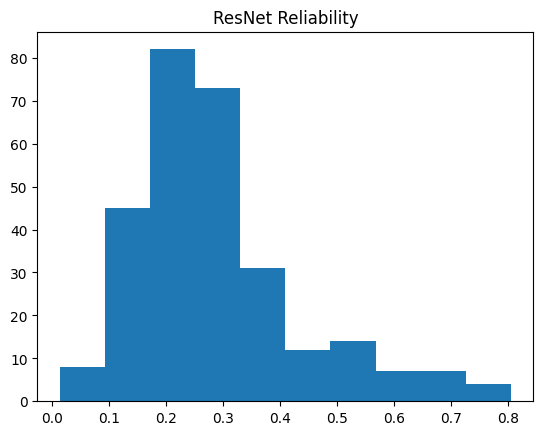

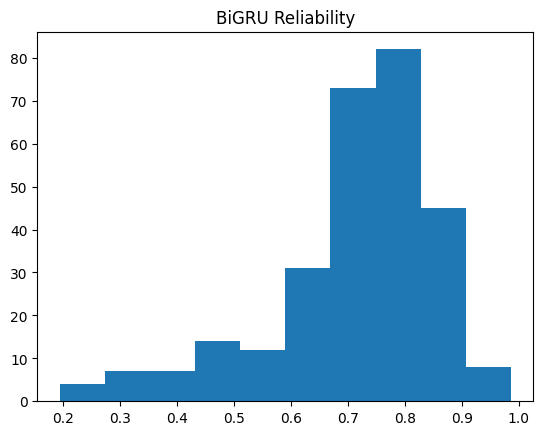

In [41]:
# Detach the tensors before converting to numpy
res_data = alpha_res.detach().cpu().numpy()
gru_data = alpha_gru.detach().cpu().numpy()

plt.hist(res_data)
plt.title("ResNet Reliability")
plt.show()

plt.hist(gru_data)
plt.title("BiGRU Reliability")
plt.show()

In [42]:
model.eval()

all_features = []
all_labels = []

with torch.no_grad():

    for res_feat, gru_feat, labels in val_loader:

        res_feat = res_feat.to(DEVICE)
        gru_feat = gru_feat.to(DEVICE)

        _, fused, _, _ = model(
            res_feat,
            gru_feat
        )

        all_features.append(fused.cpu())
        all_labels.append(labels)

features = torch.cat(all_features).numpy()
labels = torch.cat(all_labels).numpy()

print(features.shape)

(4626, 512)


In [43]:
# ============================================================
# Module 30A : Collect Validation Predictions
# ============================================================

from sklearn.metrics import roc_auc_score
import numpy as np

model.eval()

all_probs = []
all_labels = []

with torch.no_grad():

    for res_feat, gru_feat, labels in val_loader:

        res_feat = res_feat.to(DEVICE)
        gru_feat = gru_feat.to(DEVICE)

        logits, _, _, _ = model(res_feat, gru_feat)

        probs = torch.sigmoid(logits)

        all_probs.extend(
            probs.cpu().numpy().flatten()
        )

        all_labels.extend(
            labels.numpy().flatten()
        )

all_probs = np.array(all_probs)
all_labels = np.array(all_labels)

print("ROC AUC:", roc_auc_score(all_labels, all_probs))

ROC AUC: 0.8891992408235467


In [44]:
# ============================================================
# Module 30B : Temperature Scaling
# ============================================================

from scipy.optimize import minimize

def nll_loss(T):

    T = T[0]

    p = 1 / (1 + np.exp(-logits / T))

    eps = 1e-8

    return -np.mean(
        labels*np.log(p+eps)
        +
        (1-labels)*np.log(1-p+eps)
    )

model.eval()

logits = []
labels = []

with torch.no_grad():

    for res_feat, gru_feat, y in val_loader:

        res_feat = res_feat.to(DEVICE)
        gru_feat = gru_feat.to(DEVICE)

        logit, _, _, _ = model(res_feat, gru_feat)

        logits.extend(logit.cpu().numpy().flatten())

        labels.extend(y.numpy().flatten())

logits = np.array(logits)
labels = np.array(labels)

opt = minimize(
    nll_loss,
    [1.0],
    method="Powell"
)

temperature = opt.x[0]

print("Optimal Temperature:", temperature)

Optimal Temperature: 1.1624847482147678


In [45]:
calibrated_probs = 1/(1+np.exp(-logits/temperature))

 from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# 1. Take a representative sample (e.g., 5,000 points)
sample_size = 2000
if len(features) > sample_size:
    indices = np.random.choice(len(features), sample_size, replace=False)
    features_subset = features[indices]
    labels_subset = labels[indices]
else:
    features_subset = features
    labels_subset = labels

# 2. PCA to 50 components (removes noise and speeds up t-SNE)
pca = PCA(n_components=50)
features_pca = pca.fit_transform(features_subset)

# 3. Fast t-SNE
tsne = TSNE(n_components=2, perplexity=40, random_state=42, n_iter=500, init='pca', learning_rate='auto')
embedding = tsne.fit_transform(features_pca)

# 4. Plot
plt.figure(figsize=(10, 8))
scatter = plt.scatter(embedding[:, 0], embedding[:, 1], c=labels_subset, cmap='viridis', s=5, alpha=0.6)
plt.colorbar(scatter, label='Class Label')
plt.title(f"t-SNE Projection (Sampled {sample_size} points)")
plt.show()

In [46]:
# ============================================================
# Module 29.5 : Collect Validation Predictions
# ============================================================

model.eval()

probs = []
preds = []
labels = []
features = []

with torch.no_grad():

    for res_feat, gru_feat, y in val_loader:

        res_feat = res_feat.to(DEVICE)
        gru_feat = gru_feat.to(DEVICE)

        logits, fused, alpha_res, alpha_gru = model(
            res_feat,
            gru_feat
        )

        probability = torch.sigmoid(logits)

        prediction = (probability > 0.5).float()

        probs.extend(probability.cpu().numpy())

        preds.extend(prediction.cpu().numpy())

        labels.extend(y.numpy())

        features.append(fused.cpu())

features = torch.cat(features).numpy()

probs = np.array(probs)

preds = np.array(preds)

labels = np.array(labels)

print(probs.shape)
print(preds.shape)
print(labels.shape)

(4626,)
(4626,)
(4626,)


Text(0.5, 1.0, 'ROC Curve')

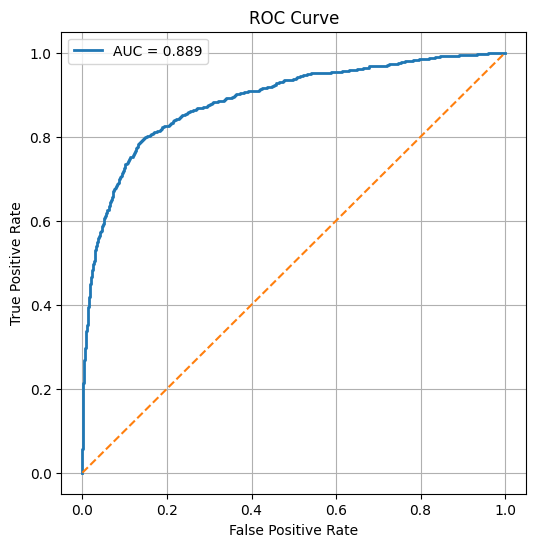

In [47]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(labels, probs)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))

plt.plot(fpr, tpr,
         label=f"AUC = {roc_auc:.3f}",
         linewidth=2)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.legend()

plt.grid()

plt.title("ROC Curve")

Text(0.5, 1.0, 'Precision Recall Curve')

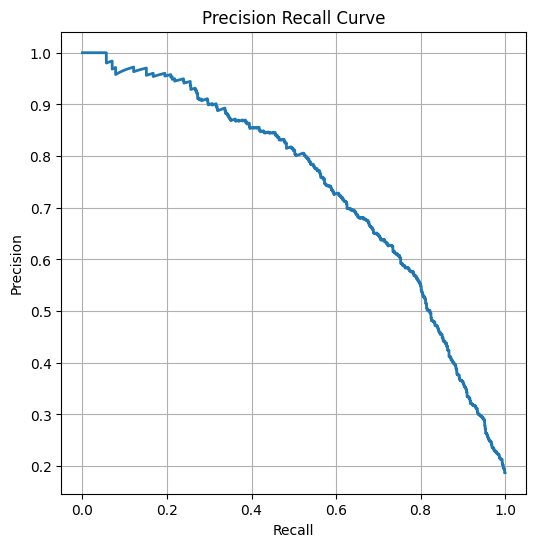

In [48]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(
    labels,
    probs
)

plt.figure(figsize=(6,6))

plt.plot(recall, precision,
         linewidth=2)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.grid()

plt.title("Precision Recall Curve")

Text(0.5, 1.0, 'Confusion Matrix')

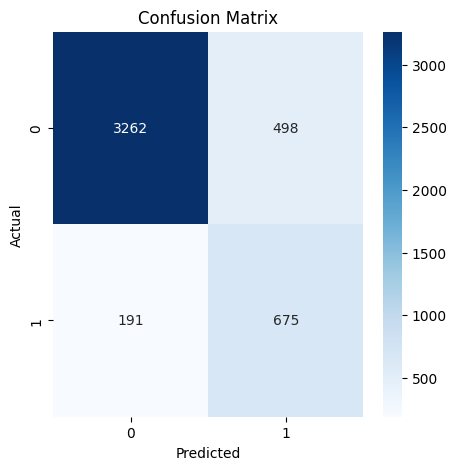

In [49]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(
    labels,
    preds
)

plt.figure(figsize=(5,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

Text(0.5, 1.0, 'Adaptive Reliability Distribution')

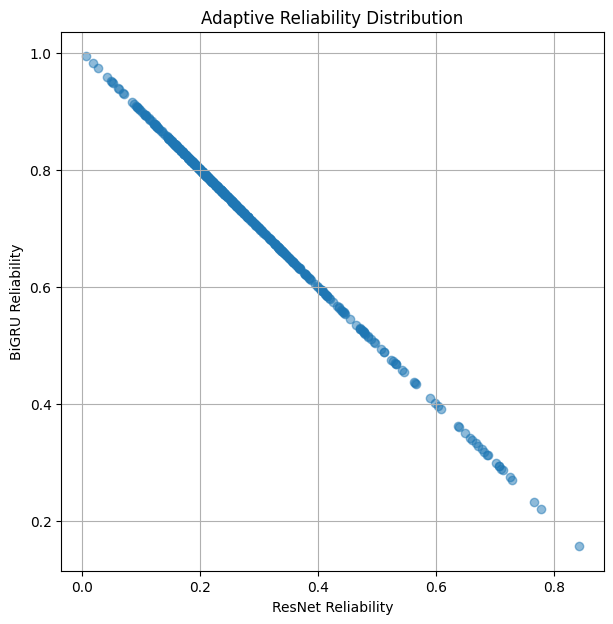

In [50]:
plt.figure(figsize=(7,7))

plt.scatter(
    alpha_res.cpu(),
    alpha_gru.cpu(),
    alpha=0.5
)

plt.xlabel("ResNet Reliability")

plt.ylabel("BiGRU Reliability")

plt.grid()

plt.title("Adaptive Reliability Distribution")

Text(0.5, 1.0, 'Calibration Curve')

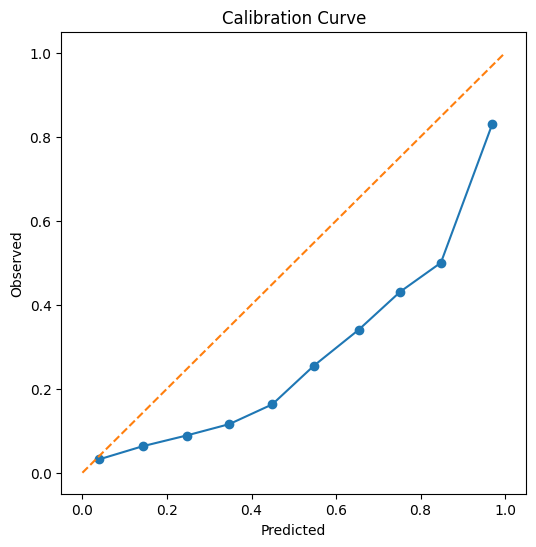

In [51]:
from sklearn.calibration import calibration_curve

true_prob,pred_prob = calibration_curve(
    labels,
    probs,
    n_bins=10
)

plt.figure(figsize=(6,6))

plt.plot(
    pred_prob,
    true_prob,
    marker='o'
)

plt.plot([0,1],[0,1],'--')

plt.xlabel("Predicted")

plt.ylabel("Observed")

plt.title("Calibration Curve")

In [52]:
# Assuming you have all_probs and all_labels from your val_loader loop
all_probs = np.array(all_probs)
all_labels = np.array(all_labels)
all_preds = (all_probs > 0.5).astype(int)

# Calculate metrics
metrics = {
    "Accuracy": accuracy_score(all_labels, all_preds),
    "Balanced Accuracy": balanced_accuracy_score(all_labels, all_preds),
    "Cohen's Kappa": cohen_kappa_score(all_labels, all_preds),
    "Precision": precision_score(all_labels, all_preds, zero_division=0),
    "Recall": recall_score(all_labels, all_preds, zero_division=0),
    "F1-Score": f1_score(all_labels, all_preds, zero_division=0),
    "ROC-AUC": roc_auc_score(all_labels, all_probs),
    "PR-AUC": average_precision_score(all_labels, all_probs),
    "MCC": matthews_corrcoef(all_labels, all_preds),
    "Log Loss": log_loss(all_labels, all_probs),
    "Brier Score": brier_score_loss(all_labels, all_probs)
}

# Print them clearly
print("--- Model Performance Metrics ---")
for name, value in metrics.items():
    print(f"{name:20}: {value:.4f}")

--- Model Performance Metrics ---
Accuracy            : 0.8511
Balanced Accuracy   : 0.8235
Cohen's Kappa       : 0.5693
Precision           : 0.5754
Recall              : 0.7794
F1-Score            : 0.6621
ROC-AUC             : 0.8892
PR-AUC              : 0.7393
MCC                 : 0.5801
Log Loss            : 0.3697
Brier Score         : 0.1121


In [53]:
torch.save(
    model.state_dict(),
    "FusionModel.pth"
)

print("Fusion model saved successfully.")

Fusion model saved successfully.


In [54]:
config = {
    "batch_size":32,
    "resnet_dim":512,
    "bigru_dim":256,
    "embed_dim":512,
    "num_heads":8,
    "dropout":0.30
}

torch.save(config,"config.pth")

In [55]:
import numpy as np
from scipy.signal import butter,filtfilt

FS = 500

b,a = butter(
    4,
    [0.5/(FS/2),40/(FS/2)],
    btype="band"
)

def preprocess(ecg):

    ecg = np.asarray(ecg).astype(np.float32)

    ecg = np.stack(
        [filtfilt(b,a,x) for x in ecg]
    )

    ecg = (
        ecg -
        ecg.mean(axis=1,keepdims=True)
    ) / (
        ecg.std(axis=1,keepdims=True)+1e-8
    )

    return ecg

In [56]:
import torch

def load_checkpoint(model,path):

    weights=torch.load(
        path,
        map_location="cpu"
    )

    model.load_state_dict(weights)

    model.eval()

    return model

In [57]:
import torch

def predict(model,ecg):

    model.eval()

    with torch.no_grad():

        ecg=torch.tensor(
            ecg,
            dtype=torch.float32
        ).unsqueeze(0)

        logits=model(ecg)

        probability=torch.sigmoid(logits)

    return probability.item()

In [58]:
BEST_THRESHOLD = 0.41

np.save(
    "threshold.npy",
    BEST_THRESHOLD
)

In [59]:
threshold=np.load(
    "threshold.npy"
)

In [60]:
label_map={

0:"Low Risk",

1:"High Risk"

}

torch.save(
    label_map,
    "labels.pth"
)

In [62]:
# =========================================================================
# Run Test Set Inference & Collect Variables for Publication Plots
# =========================================================================
model.eval()

all_probs = []
all_labels = []
all_alpha_res = []
all_alpha_gru = []

with torch.no_grad():
    for res_b, gru_b, labels_b in test_loader:
        res_b = res_b.to(DEVICE)
        gru_b = gru_b.to(DEVICE)
        
        logits, _, alpha_res_b, alpha_gru_b = model(res_b, gru_b)
        probs_b = torch.sigmoid(logits)
        
        all_probs.extend(probs_b.cpu().numpy())
        all_labels.extend(labels_b.numpy())
        all_alpha_res.extend(alpha_res_b.cpu().numpy())
        all_alpha_gru.extend(alpha_gru_b.cpu().numpy())

# Convert lists to NumPy arrays with expected names
probs = np.array(all_probs)
labels_all = np.array(all_labels)
alpha_res = np.array(all_alpha_res)
alpha_gru = np.array(all_alpha_gru)

# Compute optimal threshold using Youden's J statistic on the ROC curve
fpr, tpr, thresholds_roc = roc_curve(labels_all, probs)
optimal_idx = np.argmax(tpr - fpr)
threshold = thresholds_roc[optimal_idx]

print(f"Inference complete! Test samples evaluated: {len(labels_all)}")
print(f"Calculated Optimal Threshold: {threshold:.4f}")

Inference complete! Test samples evaluated: 5442
Calculated Optimal Threshold: 0.4697


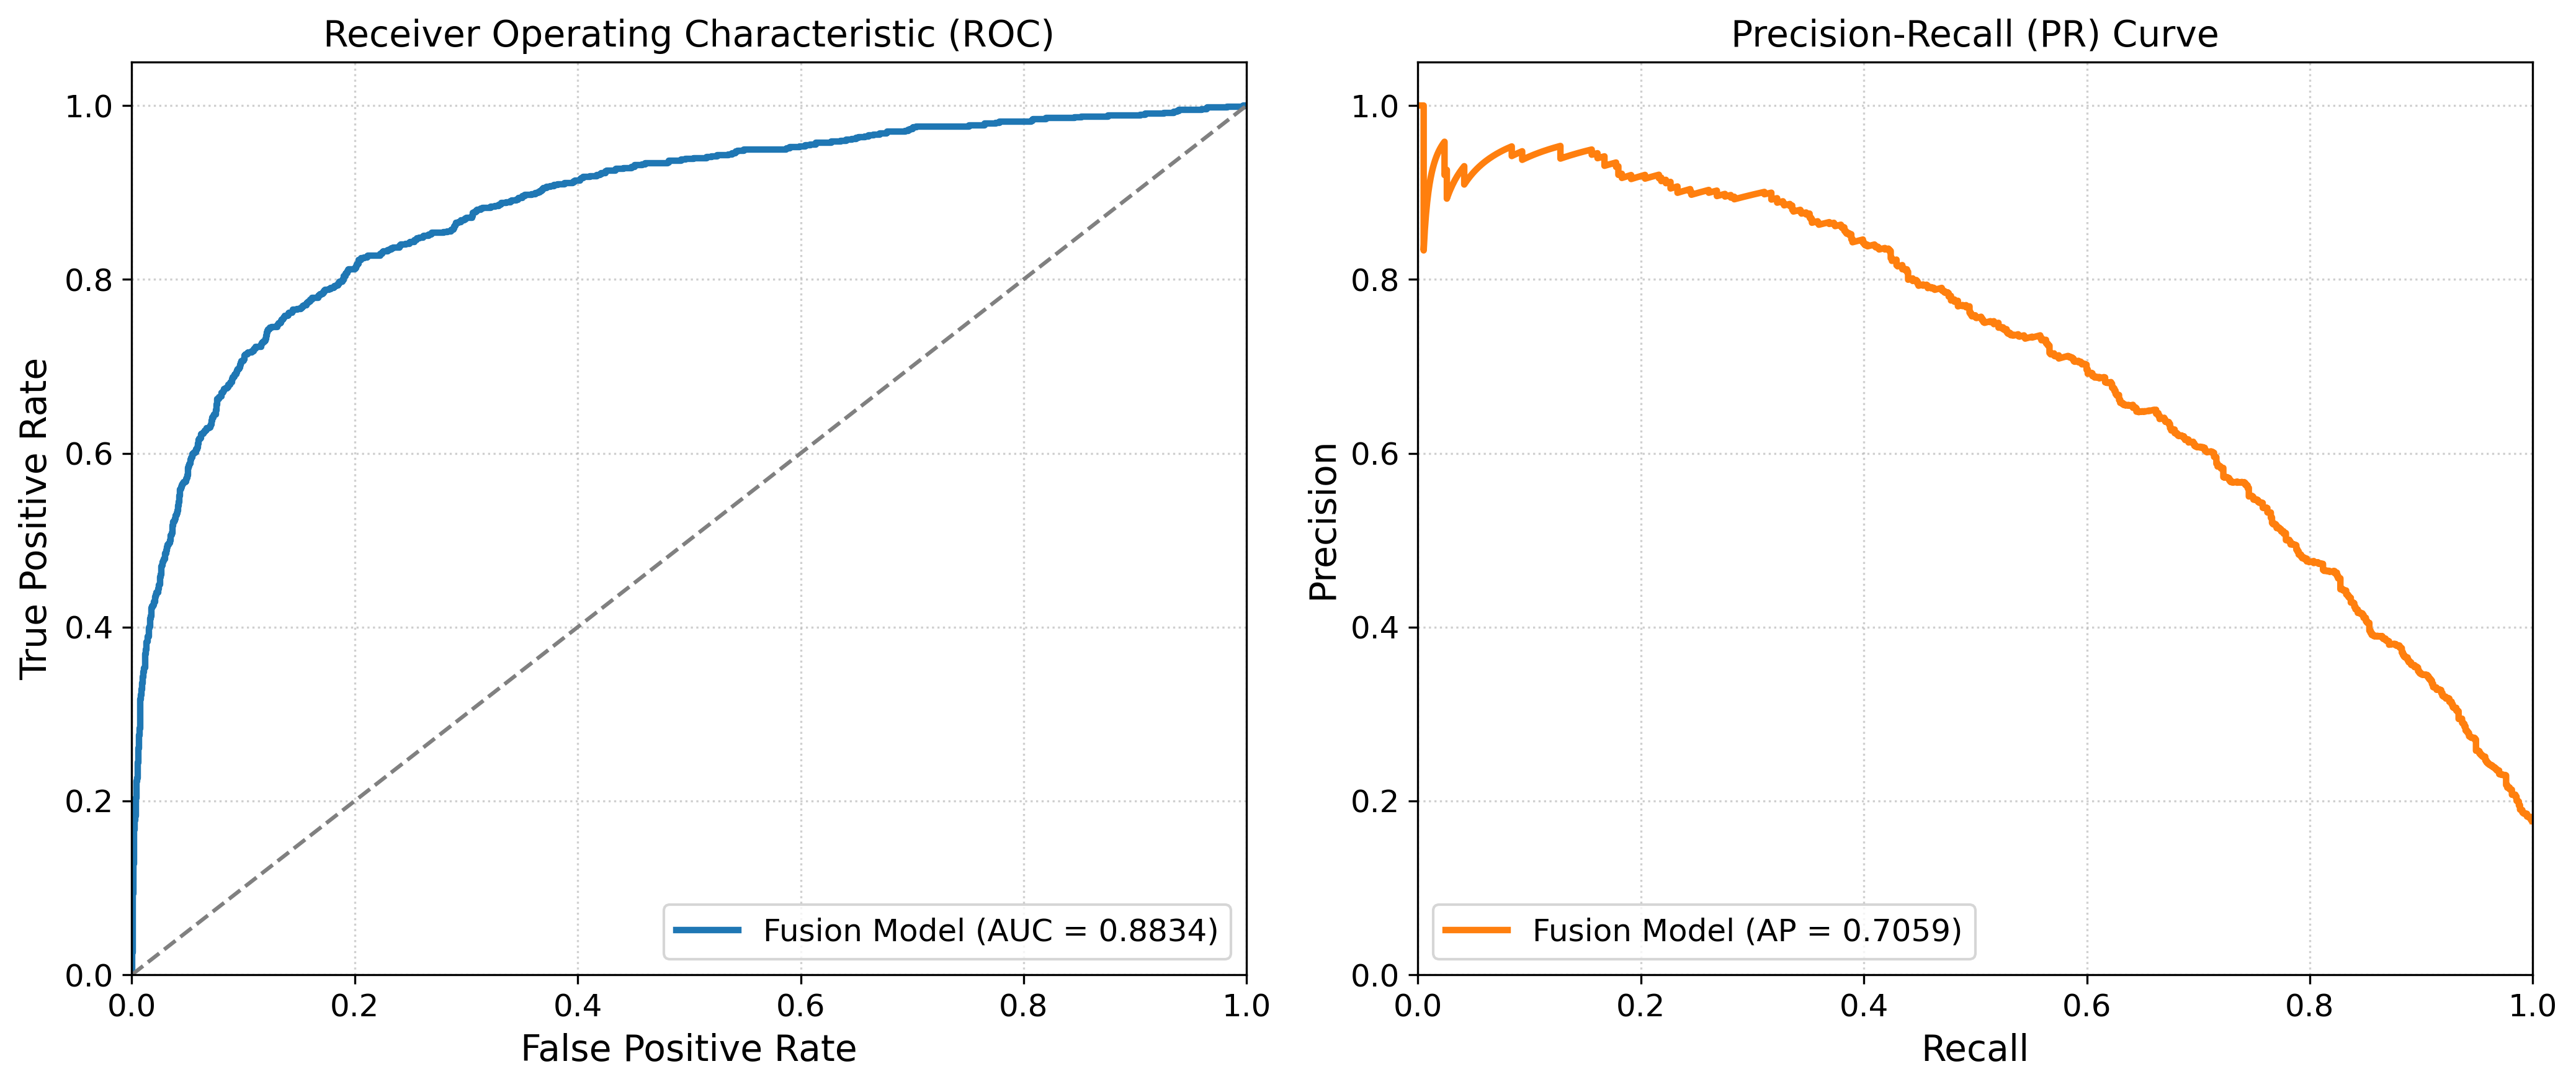

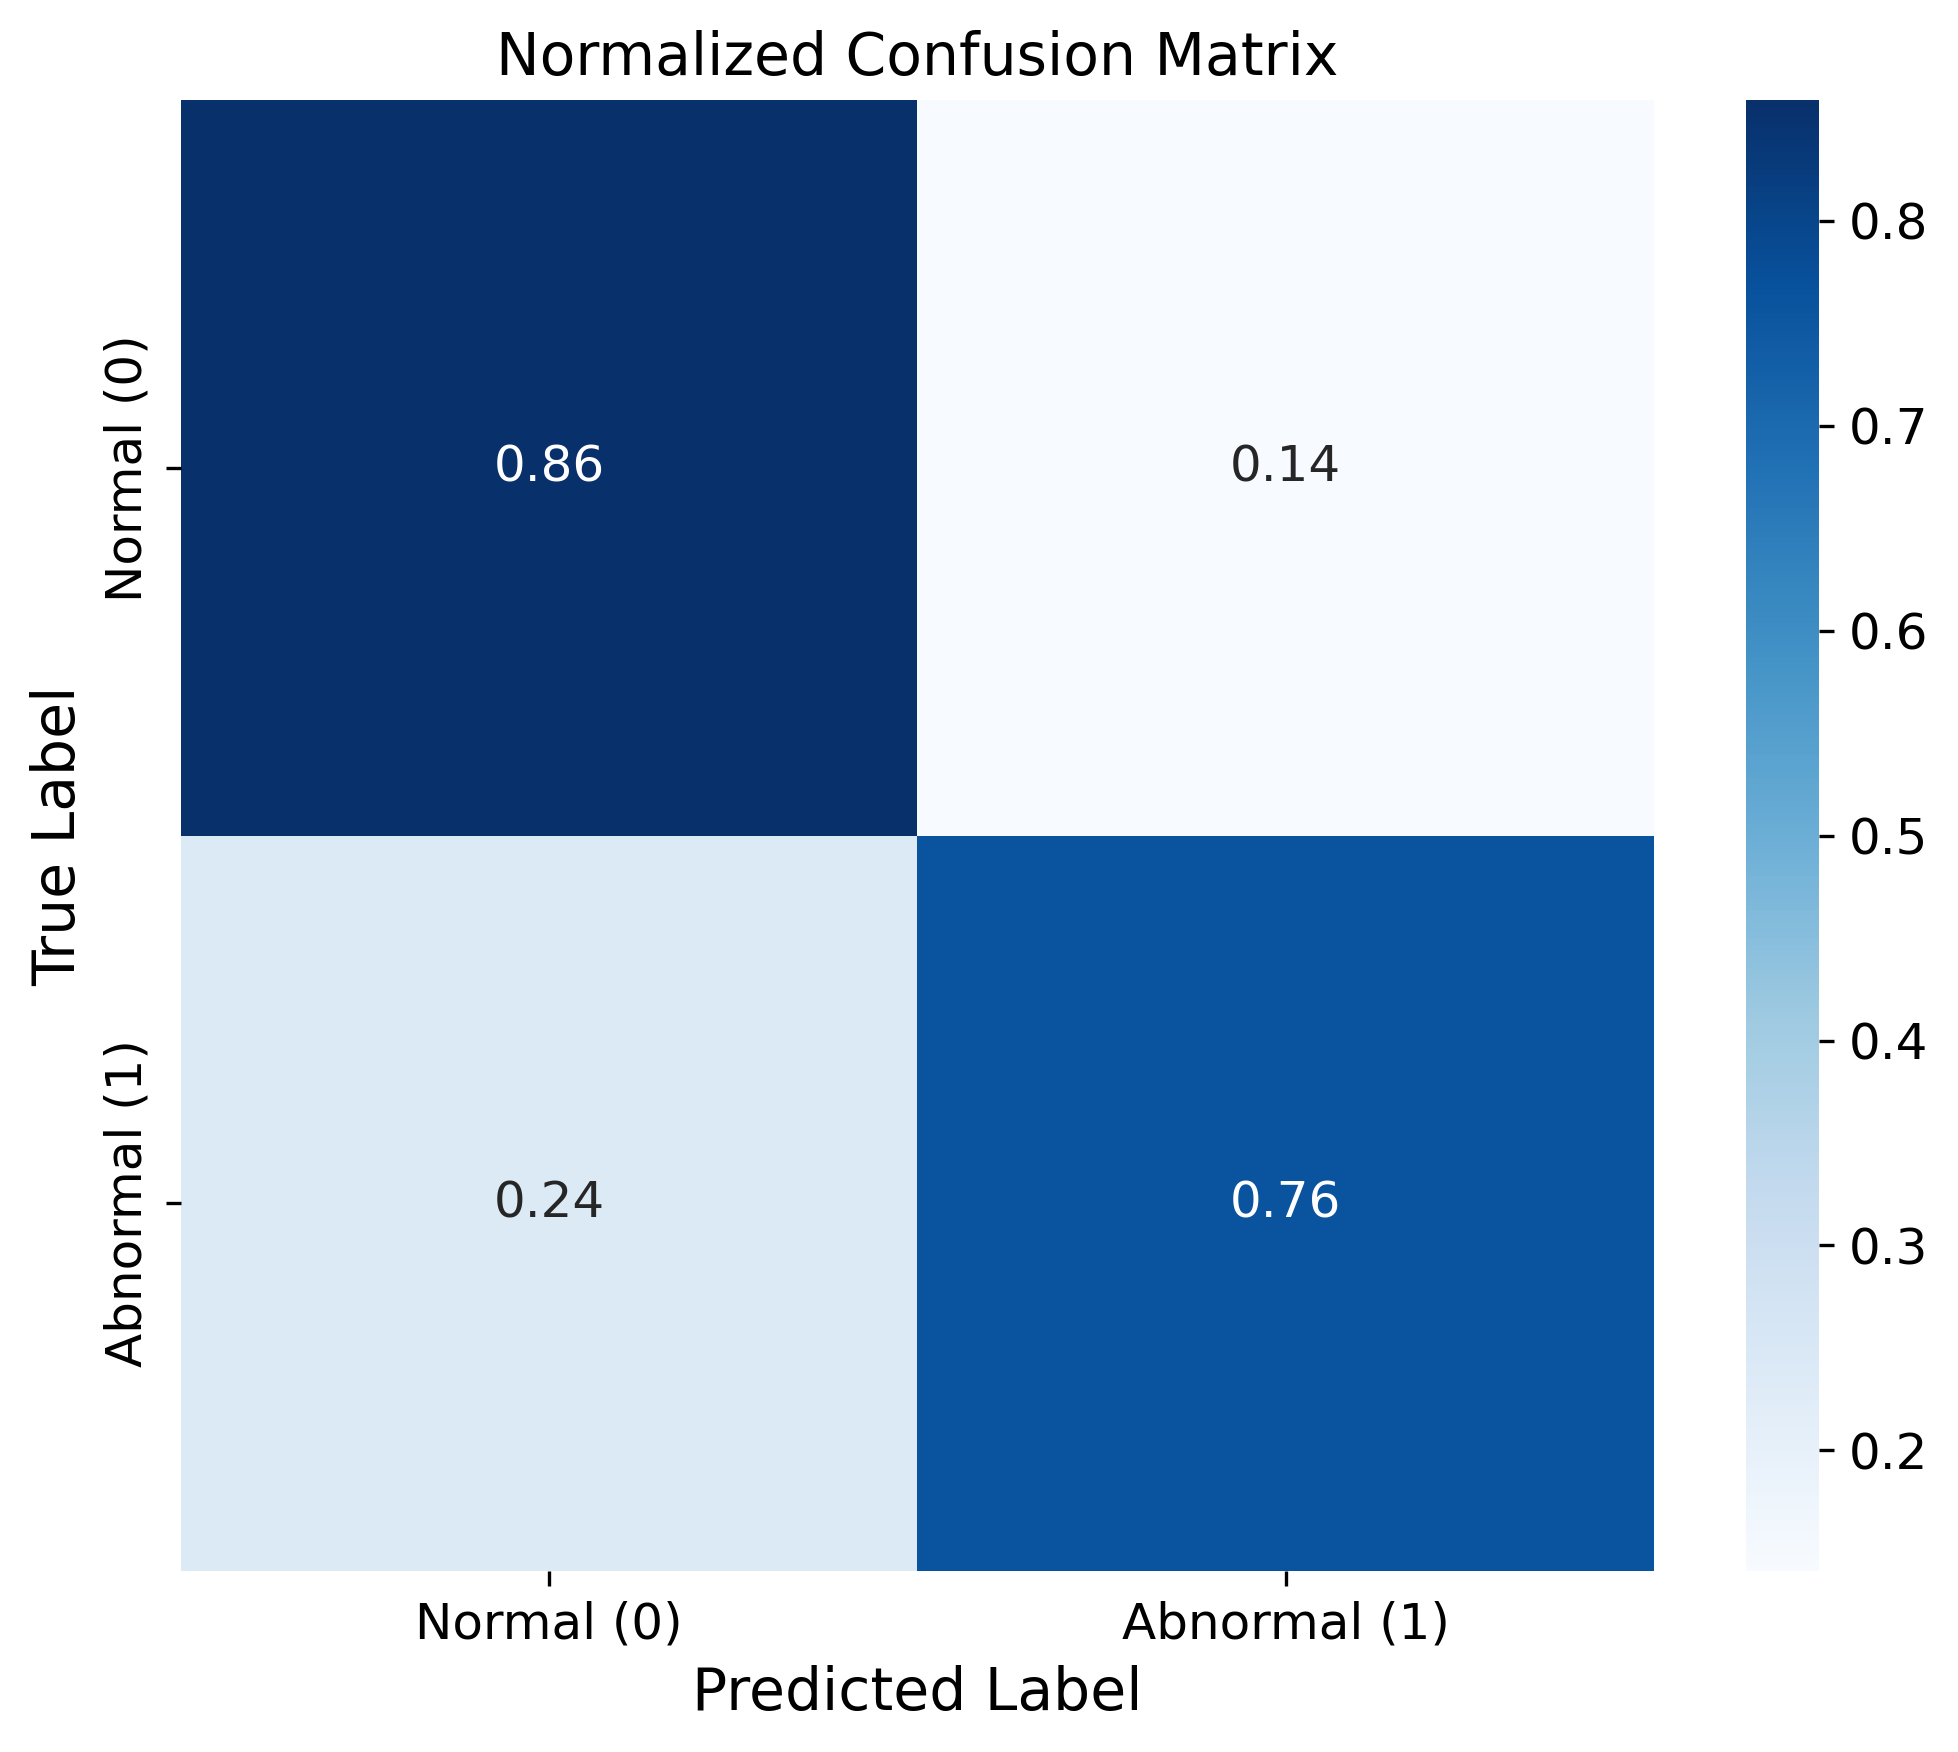

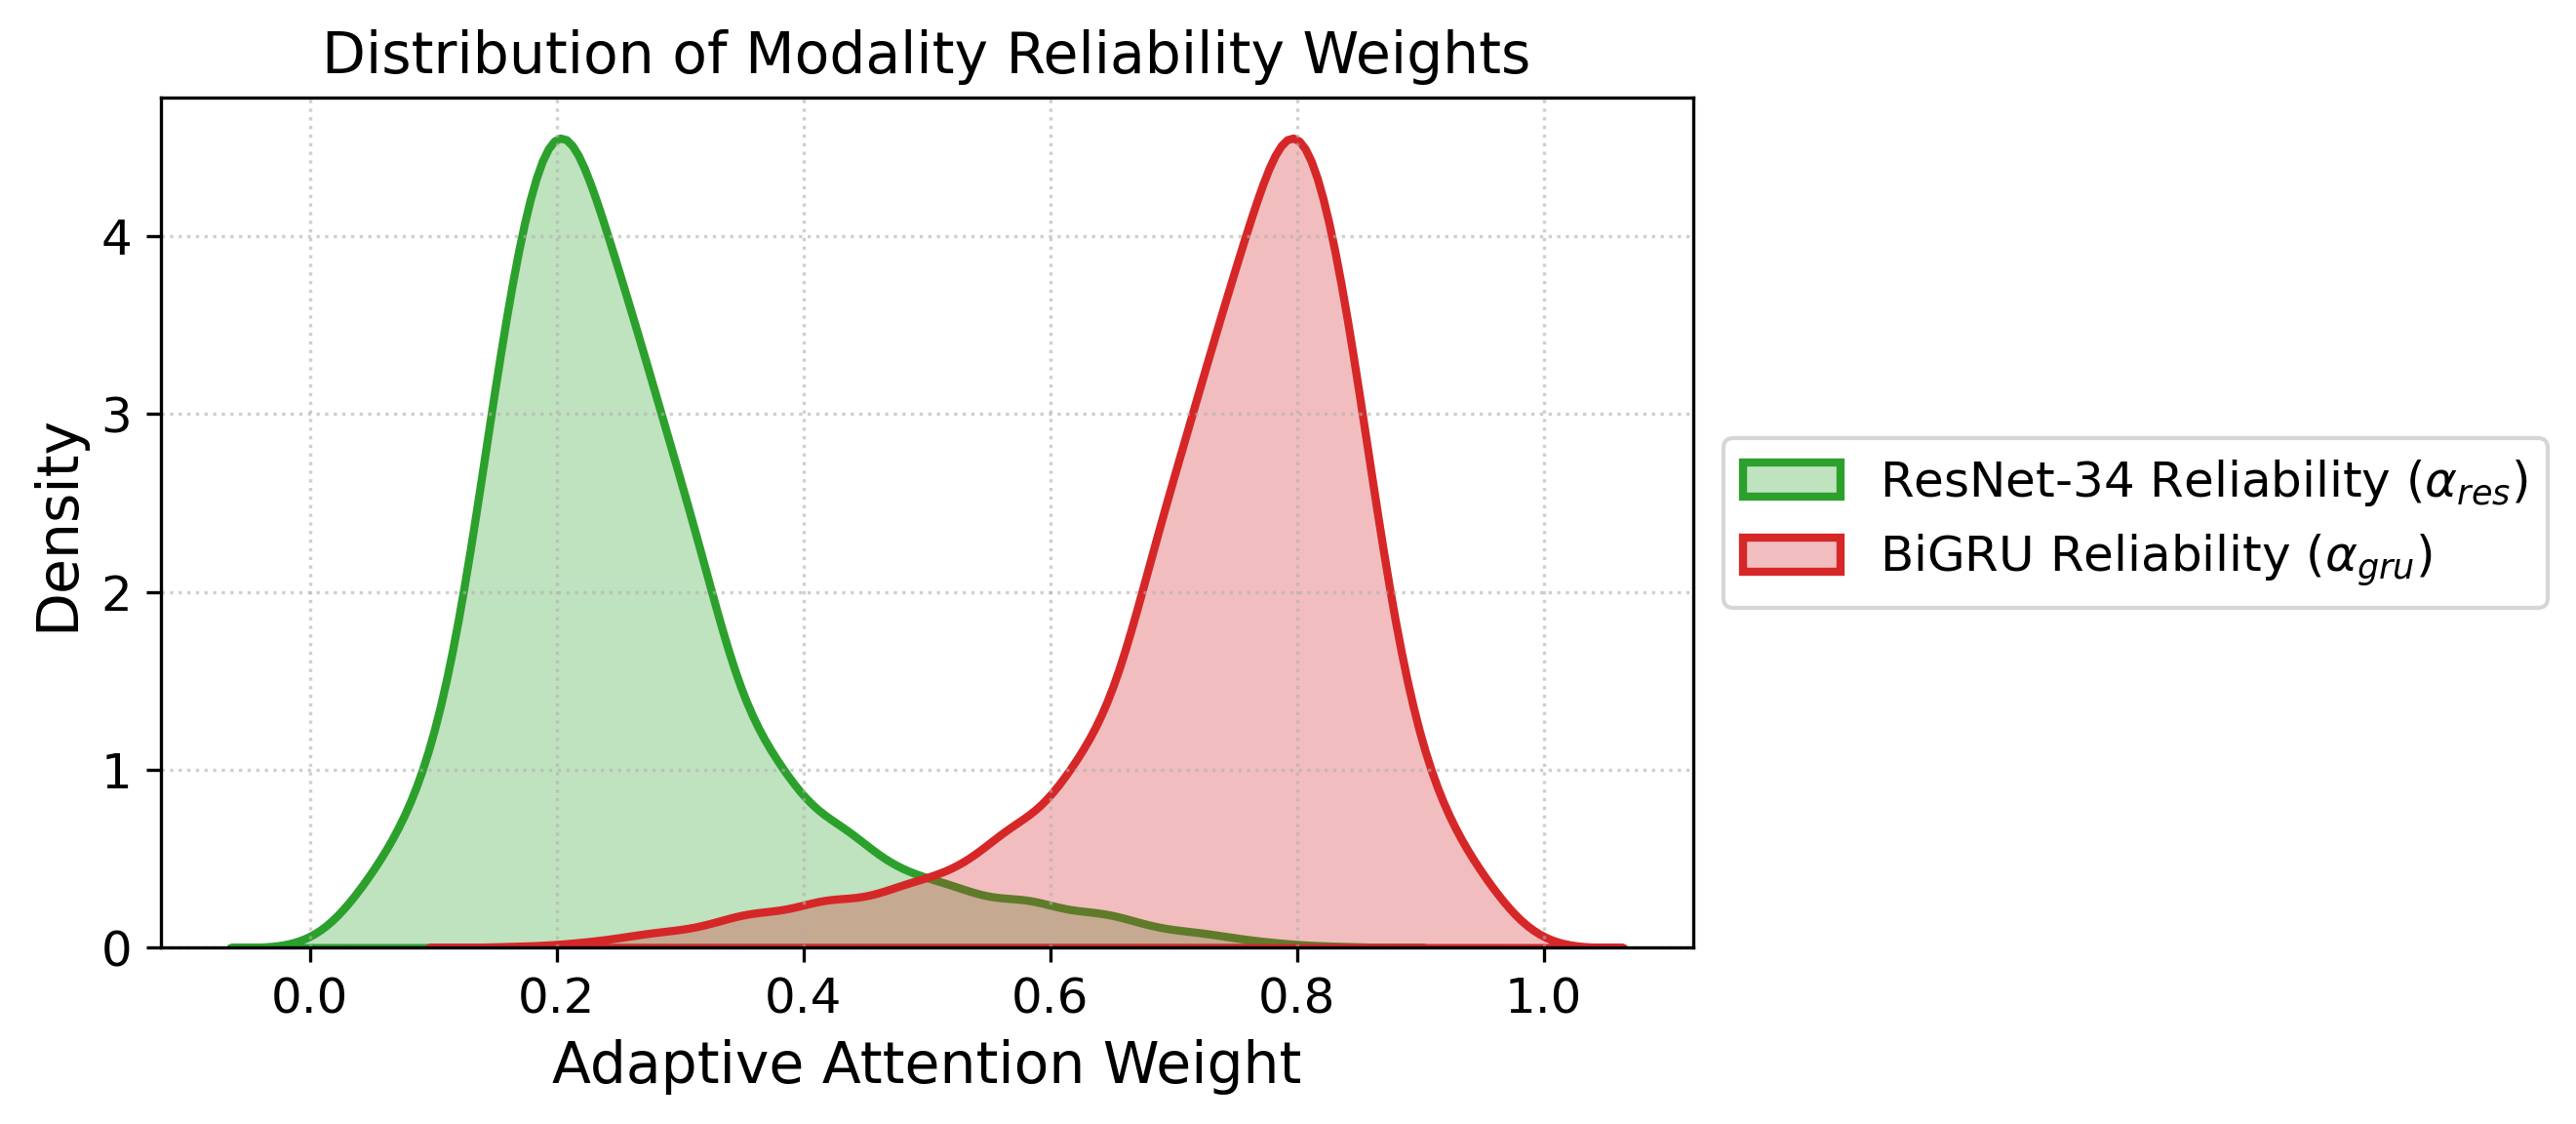

In [74]:
# ============================================================
# Research Paper Visualizations: Evaluation & Interpretability
# ============================================================
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    roc_curve, precision_recall_curve, confusion_matrix,
    roc_auc_score, average_precision_score
)

# Publication style defaults
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'figure.titlesize': 16,
    'figure.dpi': 300
})

model.eval()

all_probs = []
all_labels = []
all_alpha_res = []
all_alpha_gru = []

with torch.no_grad():
    for res_b, gru_b, labels_b in test_loader:
        res_b = res_b.to(DEVICE)
        gru_b = gru_b.to(DEVICE)
        
        logits, _, alpha_res_b, alpha_gru_b = model(res_b, gru_b)
        probs_b = torch.sigmoid(logits)
        
        all_probs.extend(probs_b.cpu().numpy())
        all_labels.extend(labels_b.numpy())
        all_alpha_res.extend(alpha_res_b.cpu().numpy())
        all_alpha_gru.extend(alpha_gru_b.cpu().numpy())

probs = np.array(all_probs)
labels_all = np.array(all_labels)
alpha_res = np.array(all_alpha_res)
alpha_gru = np.array(all_alpha_gru)

# Optimal threshold via Youden's J statistic
fpr, tpr, thresholds_roc = roc_curve(labels_all, probs)
optimal_idx = np.argmax(tpr - fpr)
threshold = thresholds_roc[optimal_idx]

# -------------------------------------------------------------------------
# 1. ROC & PR Curves
# -------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

roc_auc = roc_auc_score(labels_all, probs)
axes[0].plot(fpr, tpr, color='#1f77b4', lw=2.5, label=f'Fusion Model (AUC = {roc_auc:.4f})')
axes[0].plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1.5)
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('Receiver Operating Characteristic (ROC)')
axes[0].legend(loc='lower right')
axes[0].grid(True, linestyle=':', alpha=0.6)

precision, recall, _ = precision_recall_curve(labels_all, probs)
pr_auc = average_precision_score(labels_all, probs)
axes[1].plot(recall, precision, color='#ff7f0e', lw=2.5, label=f'Fusion Model (AP = {pr_auc:.4f})')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall (PR) Curve')
axes[1].legend(loc='lower left')
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# -------------------------------------------------------------------------
# 2. Confusion Matrix
# -------------------------------------------------------------------------
preds_binary = (probs >= threshold).astype(int)
cm = confusion_matrix(labels_all, preds_binary, normalize='true')

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', cbar=True,
            xticklabels=['Normal (0)', 'Abnormal (1)'],
            yticklabels=['Normal (0)', 'Abnormal (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Normalized Confusion Matrix')
plt.tight_layout()
plt.show()

# -------------------------------------------------------------------------
# 3. Modality Reliability Distributions (Fixed LaTeX string literals)
# -------------------------------------------------------------------------
plt.figure(figsize=(9, 4))
sns.kdeplot(alpha_res.squeeze(), label=r'ResNet-34 Reliability ($\alpha_{res}$)', color='#2ca02c', fill=True, alpha=0.3, lw=2)
sns.kdeplot(alpha_gru.squeeze(), label=r'BiGRU Reliability ($\alpha_{gru}$)', color='#d62728', fill=True, alpha=0.3, lw=2)
plt.xlabel('Adaptive Attention Weight')
plt.ylabel('Density')
plt.title('Distribution of Modality Reliability Weights')
plt.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), borderaxespad=0.)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()